In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available: False
Device: CPU


In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\FAIZ SIDDIQUI\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torchaudio


Starting VAE training and facial attribute analysis...

1. Initializing VAE...

2. Loading the data...

3. Training VAE...
Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - kl_loss: 15.4904 - loss: 2586.4922 - reconstruction_loss: 2571.0012
Epoch 1: saving model to vae_checkpoints/vae_epoch_01.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - kl_loss: 25.8117 - loss: 2447.7966 - reconstruction_loss: 2421.9844 - val_kl_loss: 34.9403 - val_loss: 2295.5405 - val_reconstruction_loss: 2260.6006
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - kl_loss: 39.1112 - loss: 2312.1843 - reconstruction_loss: 2273.0735
Epoch 2: saving model to vae_checkpoints/vae_epoch_02.weights.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - kl_loss: 40.1399 - loss: 2299.8516 - reconstruction_loss: 2259.7119 - val_kl_loss: 42.3310 - val_loss: 2259.8960 - val_reconstruction_loss: 2217.5654
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - kl_loss: 40.5823 - loss: 2270.3899 - reconstruction_lo

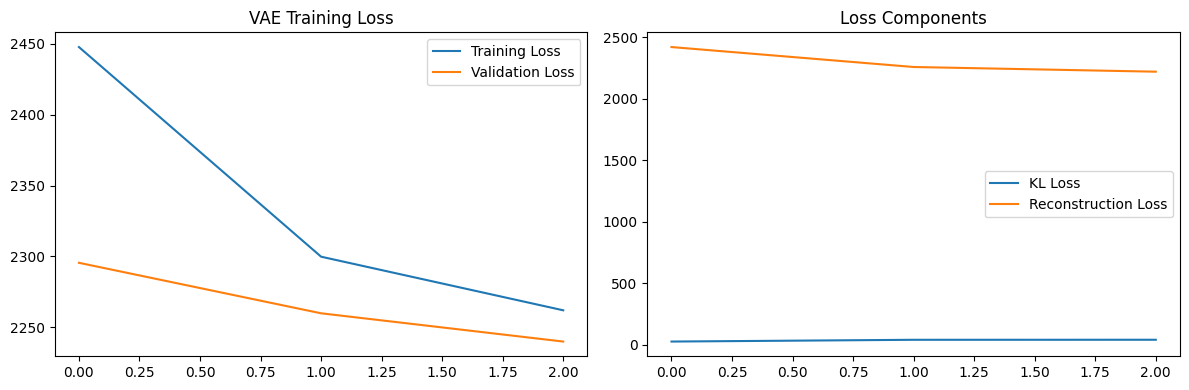


5. Analyzing latent space for attribute control...
Encoding dataset to latent space...
Encoded 5000 images to 128D latent space

Analyzing latent dimensions for attribute control...

Analyzing Smiling...
Top correlated dimensions for Smiling: [12 56  8 31 79]
Correlations: ['0.158', '0.155', '0.154', '0.145', '0.139']

Analyzing Eyes_Open...
Top correlated dimensions for Eyes_Open: [ 41  80  61  82 100]
Correlations: ['0.041', '0.041', '0.041', '0.036', '0.036']

Analyzing Black_Hair...
Top correlated dimensions for Black_Hair: [ 43  52 106 127 113]
Correlations: ['0.211', '0.197', '0.195', '0.194', '0.164']

Validating discovered attribute dimensions...
Smiling - Dimension 12: 0.438 accuracy
Eyes_Open - Dimension 41: 0.482 accuracy
Black_Hair - Dimension 43: 0.576 accuracy

6. Creating attribute mapping table...

ATTRIBUTE-LATENT DIMENSION MAPPING TABLE
Attribute: Smiling
  Primary Latent Dimension: 12
  Correlation Strength: 0.158
  Validation Accuracy: 0.438
  Discovery Method: Pea

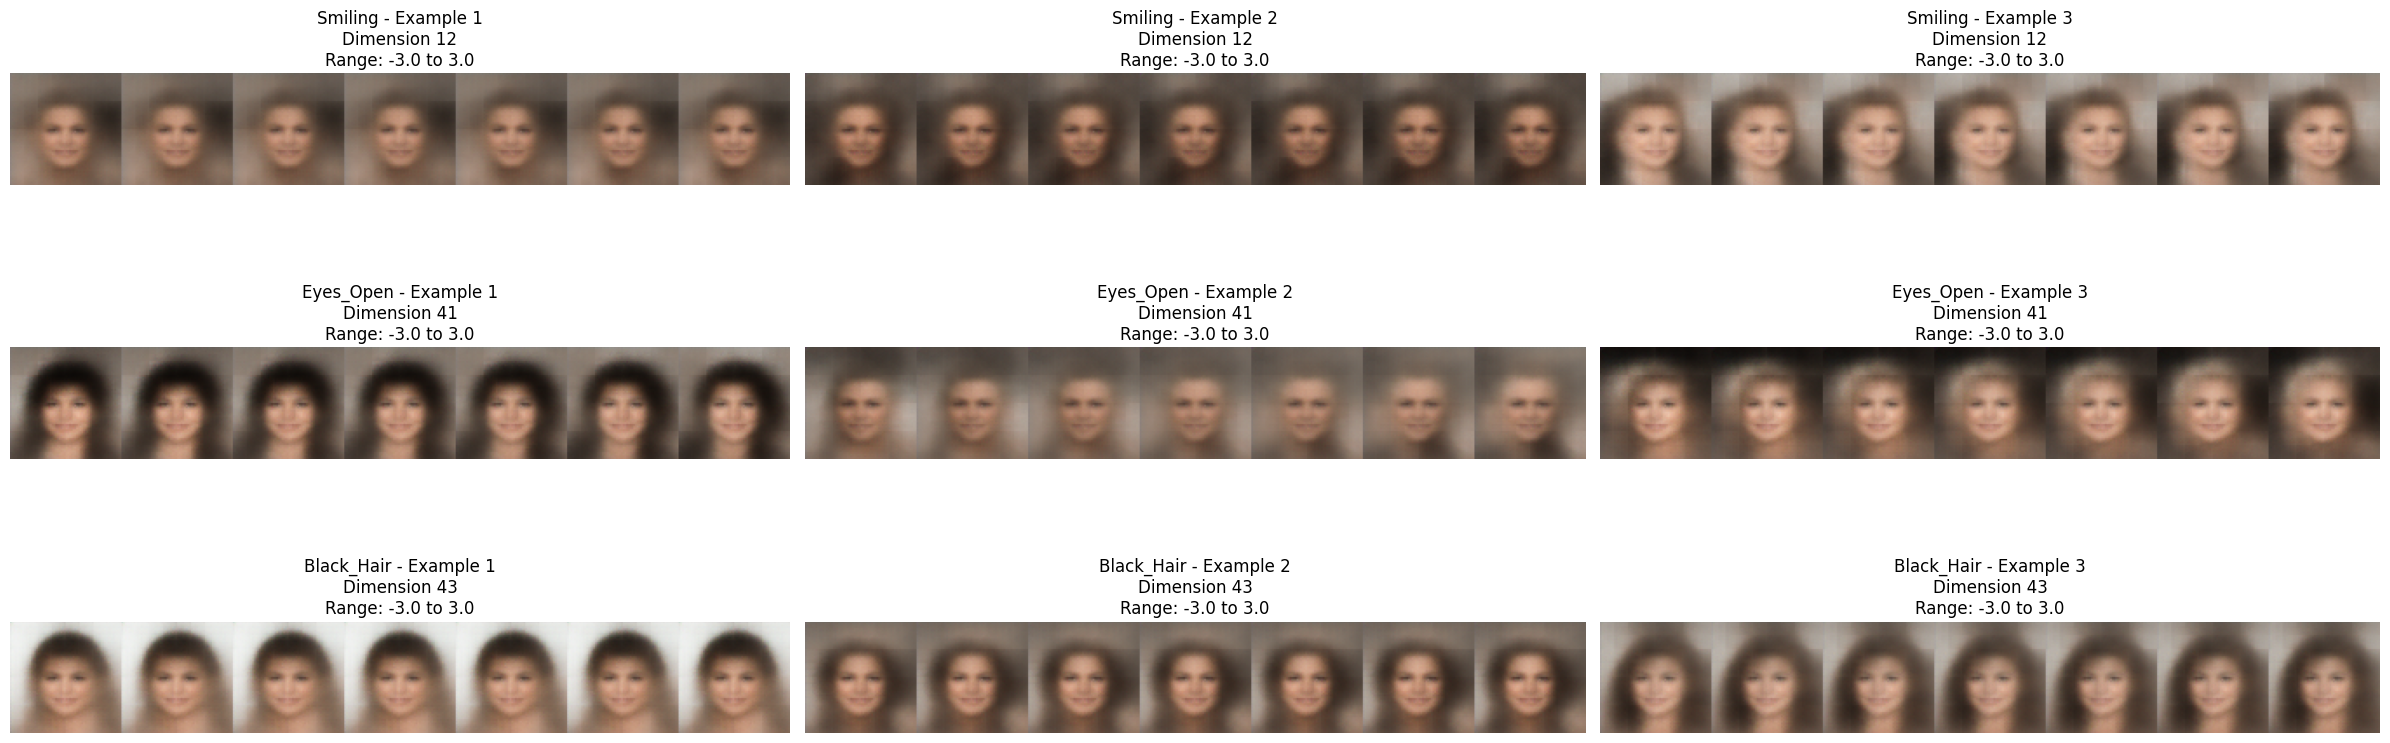

Generating comparison grid...


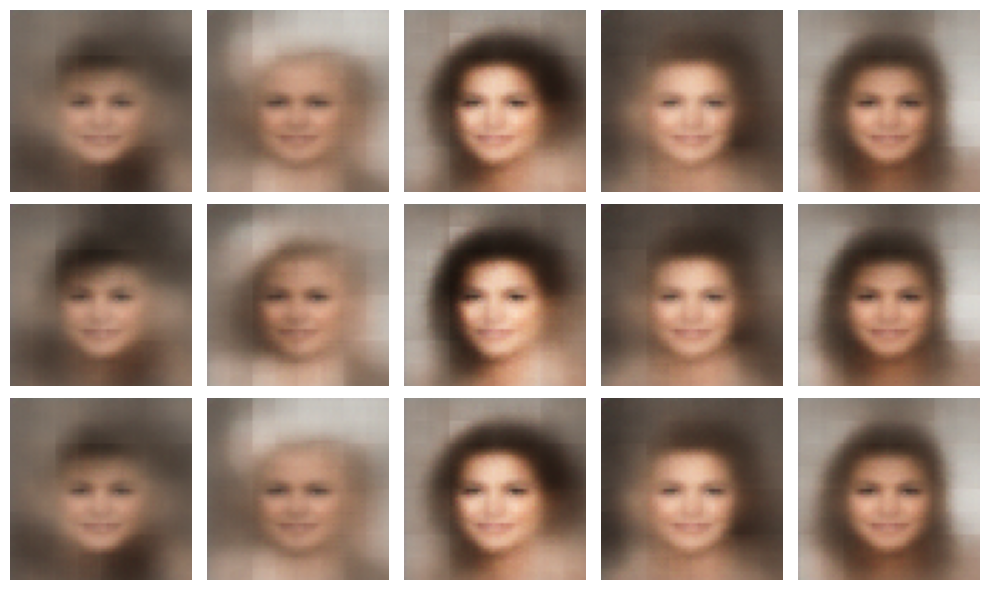


8. Saving model and results...

Analysis complete! Files saved:
- vae_weights: Trained VAE model weights
- attribute_mappings.csv: Attribute-dimension mapping table
- training_history.png: Training loss plots
- attribute_sequences.png: Generated image sequences
- attribute_comparison_grid.png: Comparison grid

VAE FACIAL ATTRIBUTE MANIPULATION - COMPLETE
Successfully trained VAE and identified attribute-controlling dimensions!
Check the generated images and mapping table for results.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

class VAE(Model):
    """Variational Autoencoder for facial attribute manipulation"""
    
    def __init__(self, latent_dim=128, img_shape=(64, 64, 3)):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.img_shape = img_shape
        
        # Build encoder and decoder
        self.encoder = self.build_encoder()
        self.decoder = self.build_decoder()
        
        # Loss tracking
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
    
    def build_encoder(self):
        """Build the encoder network"""
        encoder = Sequential([
            layers.InputLayer(input_shape=self.img_shape),
            
            # First conv block
            layers.Conv2D(32, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Second conv block
            layers.Conv2D(64, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Third conv block
            layers.Conv2D(128, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Fourth conv block
            layers.Conv2D(256, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Flatten and dense layers
            layers.Flatten(),
            layers.Dense(512),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            
            # Output mean and log variance
            layers.Dense(self.latent_dim * 2)  # mean and log_var
        ], name='encoder')
        
        return encoder
    
    def build_decoder(self):
        """Build the decoder network"""
        decoder = Sequential([
            layers.InputLayer(input_shape=(self.latent_dim,)),
            
            # Dense layers
            layers.Dense(512),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            
            layers.Dense(4 * 4 * 256),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            layers.Reshape((4, 4, 256)),
            
            # First deconv block
            layers.Conv2DTranspose(128, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Second deconv block
            layers.Conv2DTranspose(64, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Third deconv block
            layers.Conv2DTranspose(32, 3, strides=2, padding='same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(0.2),
            
            # Output layer
            layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')
        ], name='decoder')
        
        return decoder
    
    def encode(self, x):
        """Encode input to latent space"""
        encoded = self.encoder(x)
        mean = encoded[:, :self.latent_dim]
        log_var = encoded[:, self.latent_dim:]
        return mean, log_var
    
    def reparameterize(self, mean, log_var):
        """Reparameterization trick"""
        batch_size = tf.shape(mean)[0]
        epsilon = tf.random.normal(shape=(batch_size, self.latent_dim))
        return mean + tf.exp(0.5 * log_var) * epsilon
    
    def decode(self, z):
        """Decode latent vector to image"""
        return self.decoder(z)
    
    def call(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decode(z)
        return reconstruction
        
    def calculate_loss(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mean, log_var
        
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # Handle the case where data might be a tuple (image, labels) or just images
        if isinstance(data, tuple):
            x = data[0]  # Extract images if data is (images, labels)
        else:
            x = data
            
        with tf.GradientTape() as tape:
            reconstruction, mean, log_var = self.calculate_loss(x)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
    
        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
    
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
    
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    
    def test_step(self, data):
        # Handle validation step
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data
            
        reconstruction, mean, log_var = self.calculate_loss(x)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2)
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
        )
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

def load_celeba_from_local(img_dir, attr_path, img_size=64, batch_size=64):
    # Load CSV and fix column names
    df = pd.read_csv(attr_path)
    df.columns = df.columns.str.strip()
    if 'image_id' not in df.columns:
        df.rename(columns={df.columns[0]: 'image_id'}, inplace=True)

    attr_cols = ['Smiling', 'Narrow_Eyes', 'Black_Hair']
    df[attr_cols] = (df[attr_cols] == 1).astype(int)
    df['Eyes_Open'] = 1 - df['Narrow_Eyes']
    df = df[['image_id', 'Smiling', 'Eyes_Open', 'Black_Hair']]

    # Build full image paths
    df['image_path'] = df['image_id'].apply(lambda x: os.path.join(img_dir, x))
    
    df = df.sample(n=50000, random_state=42).reset_index(drop=True)
    
    train_split = 0.6
    val_split = 0.3
    test_split = 0.1
    
    # First split off the test set
    train_val_df, test_df = train_test_split(df, test_size=test_split, random_state=42)
    
    # Then split the remaining data into train and validation sets
    val_ratio_adjusted = val_split / (train_split + val_split)
    train_df, val_df = train_test_split(train_val_df, test_size=val_ratio_adjusted, random_state=42)

    # Helper to build tf.data.Dataset from DataFrame
    def df_to_dataset(sub_df):
        image_paths = sub_df['image_path'].tolist()
        labels = sub_df[['Smiling', 'Eyes_Open', 'Black_Hair']].values.astype('float32')

        path_ds = tf.data.Dataset.from_tensor_slices((image_paths, labels[:, 0], labels[:, 1], labels[:, 2]))

        def preprocess_fn(image_path, smiling, eyes_open, black_hair):
            image = tf.io.read_file(image_path)
            image = tf.image.decode_jpeg(image, channels=3)
            image = tf.image.resize(image, [img_size, img_size])
            image = tf.cast(image, tf.float32) / 255.0
            attrs = tf.stack([smiling, eyes_open, black_hair])
            return image, attrs

        ds = path_ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    return df_to_dataset(train_df), df_to_dataset(val_df), df_to_dataset(test_df)

class LatentAnalyzer:
    """Analyze and identify attribute-controlling latent dimensions"""
    
    def __init__(self, vae, images, attributes):
        self.vae = vae
        self.images = images
        self.attributes = attributes
        self.attr_names = ['Smiling', 'Eyes_Open', 'Black_Hair']
        self.latent_encodings = None
        self.attribute_mappings = {}
        
    def encode_dataset(self):
        """Encode all images to latent space"""
        print("Encoding dataset to latent space...")
        
        # Batch encoding to avoid memory issues
        latent_means = []
        batch_size = 32
        
        for i in range(0, len(self.images), batch_size):
            batch = self.images[i:i+batch_size]
            mean, _ = self.vae.encode(batch)
            latent_means.append(mean.numpy())
        
        self.latent_encodings = np.vstack(latent_means)
        print(f"Encoded {len(self.latent_encodings)} images to {self.vae.latent_dim}D latent space")
        
    def find_attribute_dimensions(self):
        """Find latent dimensions that correlate with each attribute"""
        if self.latent_encodings is None:
            self.encode_dataset()
        
        print("\nAnalyzing latent dimensions for attribute control...")
        
        for attr_idx, attr_name in enumerate(self.attr_names):
            print(f"\nAnalyzing {attr_name}...")
            
            # Calculate correlation between each latent dimension and the attribute
            correlations = []
            for dim in range(self.vae.latent_dim):
                corr = np.corrcoef(self.latent_encodings[:, dim], self.attributes[:, attr_idx])[0, 1]
                # Handle NaN correlations (when variance is zero)
                if np.isnan(corr):
                    corr = 0.0
                correlations.append(abs(corr))
            
            # Find dimensions with highest correlation
            correlations = np.array(correlations)
            top_dims = np.argsort(correlations)[-5:][::-1]  # Top 5 dimensions
            
            # Store mapping
            self.attribute_mappings[attr_name] = {
                'primary_dim': top_dims[0],
                'correlations': correlations[top_dims],
                'top_dims': top_dims
            }
            
            print(f"Top correlated dimensions for {attr_name}: {top_dims}")
            print(f"Correlations: {[f'{corr:.3f}' for corr in correlations[top_dims]]}")
        
        return self.attribute_mappings
    
    def validate_dimensions(self):
        """Validate discovered dimensions using classification"""
        print("\nValidating discovered attribute dimensions...")
        
        results = {}
        for attr_name in self.attr_names:
            attr_idx = self.attr_names.index(attr_name)
            primary_dim = self.attribute_mappings[attr_name]['primary_dim']
            
            # Use latent dimension values to predict attribute
            dim_values = self.latent_encodings[:, primary_dim]
            threshold = np.median(dim_values)
            predictions = (dim_values > threshold).astype(int)
            
            # Calculate accuracy
            accuracy = accuracy_score(self.attributes[:, attr_idx], predictions)
            results[attr_name] = {
                'dimension': primary_dim,
                'accuracy': accuracy,
                'threshold': threshold
            }
            
            print(f"{attr_name} - Dimension {primary_dim}: {accuracy:.3f} accuracy")
        
        return results

class ImageGenerator:
    """Generate images with controlled attribute manipulation"""
    
    def __init__(self, vae, attribute_mappings):
        self.vae = vae
        self.attribute_mappings = attribute_mappings
        
    def generate_attribute_sequence(self, base_latent=None, attribute='Smiling', 
                                   steps=7, variation_range=(-3, 3)):
        """Generate sequence of images by varying a specific attribute"""
        if base_latent is None:
            # Generate random base latent vector
            base_latent = tf.random.normal((1, self.vae.latent_dim))
        
        # Get the primary dimension for this attribute
        primary_dim = self.attribute_mappings[attribute]['primary_dim']
        
        # Create variations
        variations = np.linspace(variation_range[0], variation_range[1], steps)
        generated_images = []
        
        for var in variations:
            # Copy base latent and modify the attribute dimension
            modified_latent = base_latent.numpy().copy()
            modified_latent[0, primary_dim] = var
            
            # Generate image
            generated_img = self.vae.decode(tf.constant(modified_latent))
            generated_images.append(generated_img[0].numpy())
        
        return np.array(generated_images), variations
    
    def generate_comparison_grid(self, n_samples=5):
        """Generate grid showing all three attributes varied"""
        print("Generating comparison grid...")
        
        # Create figure
        fig, axes = plt.subplots(len(self.attribute_mappings), n_samples, 
                                figsize=(n_samples*2, len(self.attribute_mappings)*2))
        
        if len(self.attribute_mappings) == 1:
            axes = axes.reshape(1, -1)
        
        # Generate base latent vectors
        base_latents = tf.random.normal((n_samples, self.vae.latent_dim))
        
        for attr_idx, (attr_name, attr_info) in enumerate(self.attribute_mappings.items()):
            for sample_idx in range(n_samples):
                # Generate sequence for this attribute
                images, _ = self.generate_attribute_sequence(
                    base_latent=base_latents[sample_idx:sample_idx+1],
                    attribute=attr_name,
                    steps=1
                )
                
                # Display image
                axes[attr_idx, sample_idx].imshow(images[0])
                axes[attr_idx, sample_idx].axis('off')
                if sample_idx == 0:
                    axes[attr_idx, sample_idx].set_ylabel(attr_name, rotation=90, size=12)
        
        plt.tight_layout()
        plt.savefig('attribute_comparison_grid.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return fig

def plot_attribute_sequences(generator, attribute_mappings, n_examples=3):
    """Plot sequences for each attribute"""
    fig, axes = plt.subplots(len(attribute_mappings), n_examples, 
                            figsize=(n_examples*8, len(attribute_mappings)*3))
    
    if len(attribute_mappings) == 1:
        axes = axes.reshape(1, -1)
    
    for attr_idx, attr_name in enumerate(attribute_mappings.keys()):
        for example_idx in range(n_examples):
            # Generate sequence
            images, variations = generator.generate_attribute_sequence(
                attribute=attr_name, steps=7
            )
            
            # Create subplot for this sequence
            ax = axes[attr_idx, example_idx]
            
            # Create a horizontal montage
            montage = np.hstack(images)
            ax.imshow(montage)
            ax.axis('off')
            ax.set_title(f'{attr_name} - Example {example_idx+1}\n'
                        f'Dimension {attribute_mappings[attr_name]["primary_dim"]}\n'
                        f'Range: {variations[0]:.1f} to {variations[-1]:.1f}')
    
    plt.tight_layout()
    plt.savefig('attribute_sequences.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

def create_mapping_table(attribute_mappings, validation_results):
    """Create a table mapping attributes to latent dimensions"""
    print("\n" + "="*80)
    print("ATTRIBUTE-LATENT DIMENSION MAPPING TABLE")
    print("="*80)
    
    table_data = []
    for attr_name in attribute_mappings.keys():
        attr_info = attribute_mappings[attr_name]
        val_info = validation_results[attr_name]
        
        table_data.append({
            'Attribute': attr_name,
            'Primary_Dimension': attr_info['primary_dim'],
            'Correlation': f"{attr_info['correlations'][0]:.3f}",
            'Validation_Accuracy': f"{val_info['accuracy']:.3f}",
            'Discovery_Method': 'Correlation Analysis + Validation'
        })
        
        print(f"Attribute: {attr_name}")
        print(f"  Primary Latent Dimension: {attr_info['primary_dim']}")
        print(f"  Correlation Strength: {attr_info['correlations'][0]:.3f}")
        print(f"  Validation Accuracy: {val_info['accuracy']:.3f}")
        print(f"  Discovery Method: Pearson correlation analysis")
        print(f"  Alternative Dimensions: {list(attr_info['top_dims'][1:])}")
        print("-" * 50)
    
    # Create DataFrame for better formatting
    df = pd.DataFrame(table_data)
    print("\nSUMMARY TABLE:")
    print(df.to_string(index=False))
    
    return df

def dummy_loss(y_true, y_pred):
    """Dummy loss function for VAE with custom train_step"""
    return tf.reduce_mean(tf.square(y_pred - y_true))

def main():
    """Main training and analysis pipeline"""
    print("Starting VAE training and facial attribute analysis...")
    
    print("\n1. Initializing VAE...")
    vae = VAE(latent_dim=128, img_shape=(64, 64, 3))

    # 2. Load real CelebA dataset
    img_dir = r"E:\Semisters\semister 7\Advance AI Lab\week 4\img_align_celeba"
    csv_path = r"E:\Semisters\semister 7\Advance AI Lab\week 4\list_attr_celeba.csv"
    print("\n2. Loading the data...")
    train_ds, val_ds, test_ds = load_celeba_from_local(img_dir, csv_path, img_size=64, batch_size=32)

    # 3. Compile and train VAE - FIXED VERSION with dummy loss
    print("\n3. Training VAE...")
    # Compile with a dummy loss (it won't be used because of custom train_step)
    vae.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=dummy_loss
    )
    
    # Build the model by calling it once
    sample_input = next(iter(train_ds.map(lambda x, y: x).take(1)))
    _ = vae(sample_input)
    
    train_ds_no_labels = train_ds.map(lambda x, y: x).take(200)
    val_ds_no_labels = val_ds.map(lambda x, y: x).take(50)

    # Create checkpoint directory
    os.makedirs('vae_checkpoints', exist_ok=True)
    
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath='vae_checkpoints/vae_epoch_{epoch:02d}.weights.h5',
        save_weights_only=True,
        save_freq='epoch',
        verbose=1
    )

    history = vae.fit(
        train_ds_no_labels,
        validation_data=val_ds_no_labels,
        epochs=3,
        callbacks=[checkpoint_callback],
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('VAE Training Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['kl_loss'], label='KL Loss')
    plt.plot(history.history['reconstruction_loss'], label='Reconstruction Loss')
    plt.title('Loss Components')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()
    
    def extract_images_and_attributes(dataset, max_samples=5000):
        images = []
        attributes = []
        for image_batch, attr_batch in dataset:
            for img, attr in zip(image_batch, attr_batch):
                images.append(img.numpy())
                attributes.append(attr.numpy())
                if len(images) >= max_samples:
                    return np.stack(images), np.stack(attributes)
        return np.stack(images), np.stack(attributes)
    
        
    # 5. Analyze latent space
    print("\n5. Analyzing latent space for attribute control...")

    # Extract from test or validation dataset
    images_np, attributes_np = extract_images_and_attributes(test_ds, max_samples=5000)
    
    analyzer = LatentAnalyzer(vae, images_np, attributes_np)
    attribute_mappings = analyzer.find_attribute_dimensions()
    validation_results = analyzer.validate_dimensions()

    
    # 6. Create mapping table
    print("\n6. Creating attribute mapping table...")
    mapping_table = create_mapping_table(attribute_mappings, validation_results)
    
    # 7. Generate controlled images
    print("\n7. Generating controlled image sequences...")
    generator = ImageGenerator(vae, attribute_mappings)
    
    # Generate sequences for each attribute
    plot_attribute_sequences(generator, attribute_mappings, n_examples=3)
    
    # Generate comparison grid
    generator.generate_comparison_grid(n_samples=5)
    
    # 8. Save model and results
    print("\n8. Saving model and results...")
    vae.save_weights('vae_weights.weights.h5')
    mapping_table.to_csv('attribute_mappings.csv', index=False)
    
    print("\nAnalysis complete! Files saved:")
    print("- vae_weights: Trained VAE model weights")
    print("- attribute_mappings.csv: Attribute-dimension mapping table")
    print("- training_history.png: Training loss plots")
    print("- attribute_sequences.png: Generated image sequences")
    print("- attribute_comparison_grid.png: Comparison grid")
    
    return vae, attribute_mappings, validation_results

# Additional utility functions for extended analysis
def interpolate_between_faces(vae, face1_latent, face2_latent, steps=10):
    """Interpolate between two faces in latent space"""
    interpolations = []
    alphas = np.linspace(0, 1, steps)
    
    for alpha in alphas:
        interpolated = (1 - alpha) * face1_latent + alpha * face2_latent
        generated = vae.decode(tf.constant(interpolated))
        interpolations.append(generated[0].numpy())
    
    return np.array(interpolations)

def analyze_latent_statistics(analyzer):
    """Analyze statistical properties of latent space"""
    if analyzer.latent_encodings is None:
        analyzer.encode_dataset()
    
    print("\nLatent Space Statistics:")
    print(f"Mean latent values: {np.mean(analyzer.latent_encodings, axis=0)[:10]}...")
    print(f"Std latent values: {np.std(analyzer.latent_encodings, axis=0)[:10]}...")
    
    # Plot latent dimension distributions
    plt.figure(figsize=(15, 10))
    for i in range(min(16, analyzer.vae.latent_dim)):
        plt.subplot(4, 4, i+1)
        plt.hist(analyzer.latent_encodings[:, i], bins=30, alpha=0.7)
        plt.title(f'Dim {i}')
    plt.tight_layout()
    plt.savefig('latent_distributions.png')
    plt.show()

if __name__ == "__main__":
    # Run the complete pipeline
    vae, attribute_mappings, validation_results = main()
    
    print("\n" + "="*80)
    print("VAE FACIAL ATTRIBUTE MANIPULATION - COMPLETE")
    print("="*80)
    print("Successfully trained VAE and identified attribute-controlling dimensions!")
    print("Check the generated images and mapping table for results.")


Starting pipeline...
Loading data...
Sample batch shape (images): (32, 64, 64, 3)
Initializing VAE...


C:\Users\FAIZ SIDDIQUI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - kl_loss: 33.2563 - loss: 2377.6248 - reconstruction_loss: 2344.3687
Epoch 1: saving model to vae_checkpoints\vae_epoch_01.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 191s 196ms/step - kl_loss: 41.3218 - loss: 2264.8345 - reconstruction_loss: 2223.5122 - val_kl_loss: 47.1927 - val_loss: 2188.2825 - val_reconstruction_loss: 2141.0898
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - kl_loss: 47.8333 - loss: 2182.7893 - reconstruction_loss: 2134.9561
Epoch 2: saving model to vae_checkpoints\vae_epoch_02.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 159s 169ms/step - kl_loss: 48.5373 - loss: 2173.7957 - reconstruction_loss: 2125.2590 - val_kl_loss: 52.5283 - val_loss: 2168.7510 - val_reconstruction_loss: 2116.2227
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - kl_loss: 49.9936 - loss: 2169.3167 - reconstruction_loss: 2119.3235
Epoch 3: saving model to vae_checkpoints\vae_epoch_03.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 150ms/st

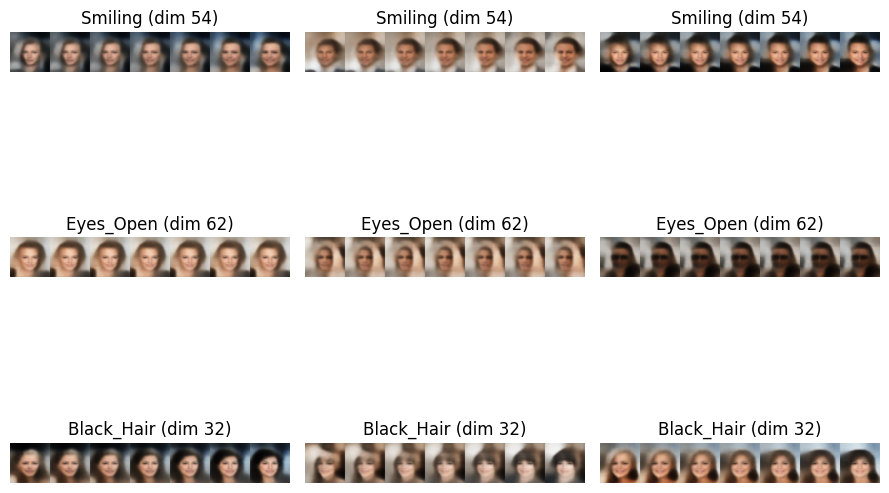

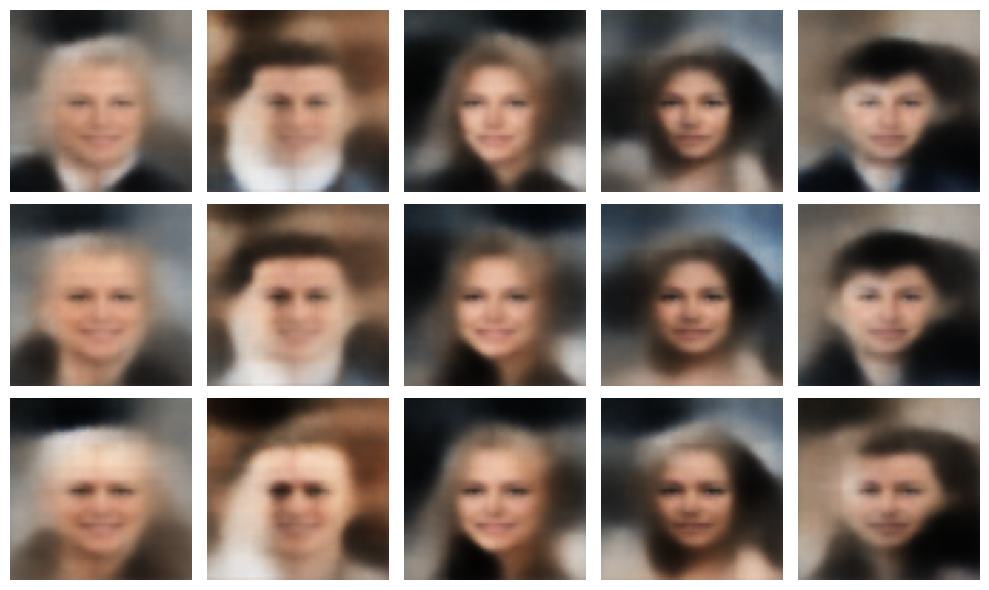

Saved final weights to vae_weights.weights.h5
Launching interactive sliders for dims: [54, 62, 32]


Output()

Done. Files saved:
- vae_checkpoints/*.weights.h5
- vae_weights.weights.h5
- attribute_mappings.csv, attribute_sequences.png, attribute_comparison_grid.png


In [5]:
# vae_attribute_slider_full_fixed.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ipywidgets (Jupyter). Safe import pattern.
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAS_IPYWIDGETS = True
except Exception:
    _HAS_IPYWIDGETS = False

# deterministic-ish behaviour
tf.random.set_seed(42)
np.random.seed(42)


class VAE(Model):
    """Variational Autoencoder with symmetric encoder/decoder and robust loss."""
    def __init__(self, latent_dim=64, img_shape=(64, 64, 3)):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.img_shape = img_shape

        self.encoder = self.build_encoder()
        self.decoder = self.build_decoder()

        # metric trackers
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def build_encoder(self):
        enc = Sequential([
            layers.InputLayer(input_shape=self.img_shape),
            layers.Conv2D(32, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2D(64, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2D(128, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2D(256, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Flatten(),
            layers.Dense(512), layers.BatchNormalization(), layers.LeakyReLU(0.2),

            # Output mean & log_var (2 * latent_dim)
            layers.Dense(self.latent_dim * 2),
        ], name="encoder")
        return enc

    def build_decoder(self):
        dec = Sequential([
            layers.InputLayer(input_shape=(self.latent_dim,)),
            layers.Dense(4 * 4 * 256),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),
            layers.Reshape((4, 4, 256)),

            layers.Conv2DTranspose(128, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2DTranspose(64, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2DTranspose(32, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            layers.Conv2DTranspose(16, 3, strides=2, padding='same'),
            layers.BatchNormalization(), layers.LeakyReLU(0.2),

            # final output 64x64x3 in [0,1]
            layers.Conv2DTranspose(3, 3, padding='same', activation='sigmoid')
        ], name="decoder")
        return dec

    def encode(self, x):
        out = self.encoder(x)
        mean = out[:, :self.latent_dim]
        log_var = out[:, self.latent_dim:]
        return mean, log_var

    def reparameterize(self, mean, log_var):
        batch = tf.shape(mean)[0]
        eps = tf.random.normal(shape=(batch, self.latent_dim))
        return mean + tf.exp(0.5 * log_var) * eps

    def decode(self, z):
        return self.decoder(z)

    def call(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        return self.decode(z)

    def calculate_loss_terms(self, x):
        """Return total, recon_loss, kl_loss, reconstruction, mean, log_var
           Reconstruction loss reduction axes are auto-detected so code works
           with inputs shaped [B,H,W] or [B,H,W,C]."""
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        recon = self.decode(z)

        # Per-pixel crossentropy shape: [batch, H, W] or [batch, H, W, C]
        per_pixel_bce = tf.keras.losses.binary_crossentropy(x, recon)

        # Auto-detect axes to reduce over (all dimensions except batch dim)
        reduce_axes = list(range(1, len(per_pixel_bce.shape)))
        # sum per pixel across spatial (+channel if present), then mean over batch
        recon_loss = tf.reduce_mean(tf.reduce_sum(per_pixel_bce, axis=reduce_axes))

        # KL divergence across latent dims, then mean over batch
        kl_per_sample = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
        kl_loss = tf.reduce_mean(kl_per_sample)

        total = recon_loss + kl_loss
        return total, recon_loss, kl_loss, recon, mean, log_var

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data
        with tf.GradientTape() as tape:
            total, recon_loss, kl_loss, recon, mean, log_var = self.calculate_loss_terms(x)
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data
        total, recon_loss, kl_loss, recon, mean, log_var = self.calculate_loss_terms(x)

        self.total_loss_tracker.update_state(total)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


# ------------------------------
# Dataset loader (local CelebA)
# ------------------------------
def load_celeba_from_local(img_dir, attr_path, img_size=64, batch_size=32, sample_n=50000):
    df = pd.read_csv(attr_path)
    df.columns = df.columns.str.strip()
    if 'image_id' not in df.columns:
        df.rename(columns={df.columns[0]: 'image_id'}, inplace=True)

    attr_cols = ['Smiling', 'Narrow_Eyes', 'Black_Hair']
    for c in attr_cols:
        if c not in df.columns:
            raise ValueError(f"CSV missing attribute column: {c}")

    df[attr_cols] = (df[attr_cols] == 1).astype(int)
    df['Eyes_Open'] = 1 - df['Narrow_Eyes']
    df = df[['image_id', 'Smiling', 'Eyes_Open', 'Black_Hair']]

    df['image_path'] = df['image_id'].apply(lambda x: os.path.join(img_dir, x))

    if sample_n is not None and sample_n < len(df):
        df = df.sample(n=sample_n, random_state=42).reset_index(drop=True)

    # Splits
    train_split, val_split, test_split = 0.6, 0.3, 0.1
    train_val_df, test_df = train_test_split(df, test_size=test_split, random_state=42)
    val_ratio_adjusted = val_split / (train_split + val_split)
    train_df, val_df = train_test_split(train_val_df, test_size=val_ratio_adjusted, random_state=42)

    def df_to_dataset(sub_df):
        image_paths = sub_df['image_path'].tolist()
        labels = sub_df[['Smiling', 'Eyes_Open', 'Black_Hair']].values.astype('float32')

        path_ds = tf.data.Dataset.from_tensor_slices((image_paths, labels[:, 0], labels[:, 1], labels[:, 2]))

        def preprocess_fn(path, s, e, h):
            image = tf.io.read_file(path)
            # ensure 3 channels (RGB). If image is grayscale, this converts to RGB.
            image = tf.image.decode_jpeg(image, channels=3)
            image = tf.image.resize(image, [img_size, img_size])
            image = tf.cast(image, tf.float32) / 255.0
            attrs = tf.stack([s, e, h])
            return image, attrs

        ds = path_ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    return df_to_dataset(train_df), df_to_dataset(val_df), df_to_dataset(test_df)


# ------------------------------
# Latent Analyzer & Image Generator
# ------------------------------
class LatentAnalyzer:
    def __init__(self, vae: VAE, images: np.ndarray, attributes: np.ndarray, attr_names=None):
        self.vae = vae
        self.images = images.astype('float32')
        self.attributes = attributes.astype('float32')
        self.attr_names = attr_names or ['Smiling', 'Eyes_Open', 'Black_Hair']
        self.latent_encodings = None
        self.attribute_mappings = {}

    def encode_dataset(self, batch_size=32):
        latent_means = []
        for i in range(0, len(self.images), batch_size):
            batch = self.images[i:i+batch_size]
            mean, _ = self.vae.encode(tf.constant(batch))
            latent_means.append(mean.numpy())
        self.latent_encodings = np.vstack(latent_means)
        print(f"Encoded {self.latent_encodings.shape[0]} samples to {self.latent_encodings.shape[1]}-D")

    def find_attribute_dimensions(self, top_k=5):
        if self.latent_encodings is None:
            self.encode_dataset()
        for ai, name in enumerate(self.attr_names):
            corrs = []
            for d in range(self.vae.latent_dim):
                corr = np.corrcoef(self.latent_encodings[:, d], self.attributes[:, ai])[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                corrs.append(abs(corr))
            corrs = np.array(corrs)
            top_dims = np.argsort(corrs)[-top_k:][::-1]
            self.attribute_mappings[name] = {
                'primary_dim': int(top_dims[0]),
                'correlations': corrs[top_dims],
                'top_dims': [int(x) for x in top_dims]
            }
            print(f"{name}: top dims {self.attribute_mappings[name]['top_dims']} "
                  f"corrs {[f'{c:.3f}' for c in self.attribute_mappings[name]['correlations']]}")
        return self.attribute_mappings

    def validate_dimensions(self):
        if self.latent_encodings is None:
            self.encode_dataset()
        results = {}
        for idx, name in enumerate(self.attr_names):
            dim = self.attribute_mappings[name]['primary_dim']
            vals = self.latent_encodings[:, dim]
            thr = np.median(vals)
            preds = (vals > thr).astype(int)
            acc = accuracy_score(self.attributes[:, idx], preds)
            results[name] = {'dimension': dim, 'accuracy': float(acc), 'threshold': float(thr)}
            print(f"{name} => dim {dim}, acc {acc:.3f}")
        return results


class ImageGenerator:
    def __init__(self, vae: VAE, attribute_mappings: dict):
        self.vae = vae
        self.attribute_mappings = attribute_mappings

    def generate_attribute_sequence(self, base_latent=None, attribute='Smiling', steps=7, variation_range=(-3, 3)):
        if base_latent is None:
            base_latent = tf.random.normal((1, self.vae.latent_dim)).numpy()
        primary = self.attribute_mappings[attribute]['primary_dim']
        variations = np.linspace(variation_range[0], variation_range[1], steps)
        imgs = []
        for v in variations:
            lat = base_latent.copy()
            lat[0, primary] = v
            gen = self.vae.decode(tf.constant(lat)).numpy()
            imgs.append(gen[0])
        return np.array(imgs), variations

    def generate_comparison_grid(self, n_samples=5, save_path='attribute_comparison_grid.png'):
        rows = list(self.attribute_mappings.keys())
        fig, axes = plt.subplots(len(rows), n_samples, figsize=(n_samples*2, len(rows)*2))
        if len(rows) == 1:
            axes = axes.reshape(1, -1)
        base_latents = tf.random.normal((n_samples, self.vae.latent_dim)).numpy()
        for r, attr in enumerate(rows):
            for s in range(n_samples):
                imgs, _ = self.generate_attribute_sequence(base_latent=base_latents[s:s+1], attribute=attr, steps=1)
                axes[r, s].imshow(imgs[0])
                axes[r, s].axis('off')
                if s == 0:
                    axes[r, s].set_ylabel(attr, rotation=90, size=12)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        return fig


# ------------------------------
# Interactive slider function (Jupyter)
# ------------------------------
def interactive_attribute_control(vae: VAE, dims, base_latent=None, step=0.1, min_val=-3.0, max_val=3.0):
    if not _HAS_IPYWIDGETS:
        raise RuntimeError("ipywidgets is not available. Run in Jupyter/Colab and install ipywidgets to use sliders.")

    if base_latent is None:
        base_latent = tf.random.normal((1, vae.latent_dim)).numpy()
    else:
        base_latent = base_latent.copy()

    sliders = {}
    for d in dims:
        sliders[str(d)] = widgets.FloatSlider(value=float(base_latent[0, d]),
                                              min=min_val, max=max_val, step=step,
                                              description=f'Dim {d}', continuous_update=True)

    out = widgets.Output()

    def render(change=None):
        latent = base_latent.copy()
        for key, w in sliders.items():
            latent[0, int(key)] = w.value
        gen = vae.decode(tf.constant(latent)).numpy()
        with out:
            out.clear_output(wait=True)
            plt.figure(figsize=(3, 3))
            plt.imshow(gen[0])
            plt.axis('off')
            plt.show()

    for w in sliders.values():
        w.observe(render, 'value')

    display(widgets.VBox(list(sliders.values())))
    display(out)
    render()


# ------------------------------
# Utilities
# ------------------------------
def extract_images_and_attributes(dataset, max_samples=5000):
    images, attrs = [], []
    for img_batch, attr_batch in dataset:
        for img, at in zip(img_batch, attr_batch):
            images.append(img.numpy())
            attrs.append(at.numpy())
            if len(images) >= max_samples:
                return np.stack(images), np.stack(attrs)
    if len(images) == 0:
        return np.zeros((0, 64, 64, 3)), np.zeros((0, 3))
    return np.stack(images), np.stack(attrs)


def plot_attribute_sequences(generator: ImageGenerator, attribute_mappings, n_examples=3, steps=7):
    n_attrs = len(attribute_mappings)
    fig, axes = plt.subplots(n_attrs, n_examples, figsize=(n_examples * 3, n_attrs * 2.5))
    if n_attrs == 1:
        axes = axes.reshape(1, -1)
    for ai, attr in enumerate(attribute_mappings.keys()):
        for ex in range(n_examples):
            images, variations = generator.generate_attribute_sequence(attribute=attr, steps=steps)
            montage = np.hstack(images)
            ax = axes[ai, ex]
            ax.imshow(montage)
            ax.axis('off')
            ax.set_title(f'{attr} (dim {attribute_mappings[attr]["primary_dim"]})')
    plt.tight_layout()
    plt.savefig('attribute_sequences.png', dpi=150, bbox_inches='tight')
    plt.show()


def create_mapping_table(attribute_mappings, validation_results, save_csv='attribute_mappings.csv'):
    rows = []
    for k, v in attribute_mappings.items():
        val = validation_results[k]
        corr = v['correlations'][0] if len(v['correlations']) > 0 else 0.0
        rows.append({
            'Attribute': k,
            'Primary_Dimension': v['primary_dim'],
            'Correlation': f"{corr:.3f}",
            'Validation_Accuracy': f"{val['accuracy']:.3f}",
            'Discovery_Method': 'Correlation analysis + median-threshold validation'
        })
        print(f"{k}: primary_dim={v['primary_dim']}, corr={corr:.3f}, val_acc={val['accuracy']:.3f}")
    df = pd.DataFrame(rows)
    df.to_csv(save_csv, index=False)
    print(f"\nSaved mapping table to {save_csv}")
    return df


# ------------------------------
# Main pipeline
# ------------------------------
def main():
    print("Starting pipeline...")

    # USER: set these paths to your local dataset
    img_dir = r"E:\Semisters\semister 7\Advance AI Lab\week 4\img_align_celeba"
    csv_path = r"E:\Semisters\semister 7\Advance AI Lab\week 4\list_attr_celeba.csv"

    # Configs
    IMG_SIZE = 64
    BATCH_SIZE = 32
    LATENT_DIM = 64
    SAMPLE_N = 50000  # or None to use all

    # 1) Prepare data
    print("Loading data...")
    train_ds, val_ds, test_ds = load_celeba_from_local(img_dir, csv_path,
                                                      img_size=IMG_SIZE,
                                                      batch_size=BATCH_SIZE,
                                                      sample_n=SAMPLE_N)

    # quick sanity check on shapes
    sample_x, sample_attrs = next(iter(train_ds.take(1)))
    print("Sample batch shape (images):", sample_x.shape)  # should be [B, H, W, 3]

    # 2) Init VAE
    print("Initializing VAE...")
    vae = VAE(latent_dim=LATENT_DIM, img_shape=(IMG_SIZE, IMG_SIZE, 3))

    # 3) Compile (custom train_step used)
    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

    # Build model (call once)
    _ = vae(sample_x)

    # 4) Setup checkpoint (weights-only must end with .weights.h5)
    os.makedirs('vae_checkpoints', exist_ok=True)
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('vae_checkpoints', 'vae_epoch_{epoch:02d}.weights.h5'),
        save_weights_only=True,
        save_freq='epoch',
        verbose=1
    )

    # Optionally resume from latest checkpoint
    latest = tf.train.latest_checkpoint('vae_checkpoints')
    if latest:
        print("Resuming from:", latest)
        vae.load_weights(latest)

    # 5) Train (images only)
    EPOCHS = 3
    train_images = train_ds.map(lambda x, y: x)
    val_images = val_ds.map(lambda x, y: x)

    history = vae.fit(train_images, validation_data=val_images, epochs=EPOCHS,
                      callbacks=[checkpoint_callback], verbose=1)

    # 6) Post-train: extract examples for analysis
    images_np, attrs_np = extract_images_and_attributes(test_ds, max_samples=5000)

    analyzer = LatentAnalyzer(vae, images_np, attrs_np,
                              attr_names=['Smiling', 'Eyes_Open', 'Black_Hair'])
    attribute_mappings = analyzer.find_attribute_dimensions(top_k=5)
    validation_results = analyzer.validate_dimensions()

    mapping_table = create_mapping_table(attribute_mappings, validation_results)

    generator = ImageGenerator(vae, attribute_mappings)
    plot_attribute_sequences(generator, attribute_mappings, n_examples=3, steps=7)
    generator.generate_comparison_grid(n_samples=5)

    vae.save_weights('vae_weights.weights.h5')
    print("Saved final weights to vae_weights.weights.h5")

    # interactive sliders (Jupyter only)
    if _HAS_IPYWIDGETS:
        dims = [attribute_mappings[a]['primary_dim'] for a in attribute_mappings.keys()]
        print("Launching interactive sliders for dims:", dims)
        interactive_attribute_control(vae, dims=dims)
    else:
        print("ipywidgets not available — interactive UI skipped.")

    print("Done. Files saved:")
    print("- vae_checkpoints/*.weights.h5")
    print("- vae_weights.weights.h5")
    print("- attribute_mappings.csv, attribute_sequences.png, attribute_comparison_grid.png")
    return vae, attribute_mappings, validation_results


if __name__ == "__main__":
    vae, attribute_mappings, validation_results = main()
